In [1]:
# Load relevant modules
import postgkyl as pg
import numpy as np
import matplotlib.pyplot as plt
import os

# plt.rcParams["figure.figsize"] = (6, 5)
# plt.rcParams["font.size"] = 12


In [11]:
# Base directory where GKYL files live
basedir = "/dartfs-hpc/rc/home/7/f006xp7/gkeyll_tests/hase_to_instability_ky_mode/"

# Output step to load
step = 0


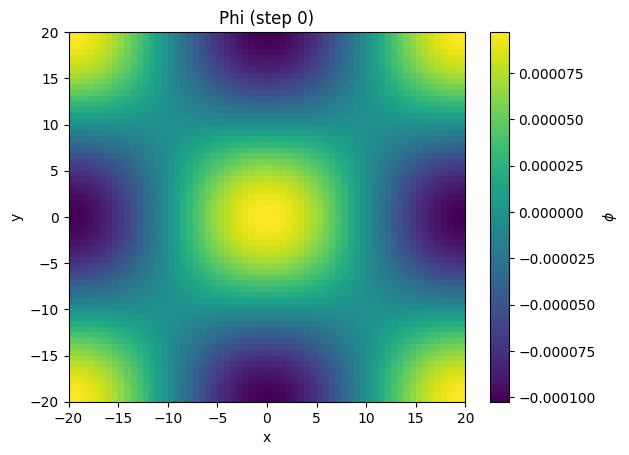

In [12]:
# Load electron density moment (modal data!)
elc_m0 = pg.data.GData(f"{basedir}/drift_wave_instability-phi_{step}.gkyl")

# Interpolate modal → nodal
# polyOrder = 1, basis = serendipity
m0Interp = pg.data.GInterpModal(elc_m0, 1, 'ms')
interpGrid, ne = m0Interp.interpolate()

# interpGrid = [x, y]
x = interpGrid[0]
y = interpGrid[1]

# ne shape: (Nx, Ny, 1)
ne2d = ne[:, :, 0]

plt.figure()
plt.pcolormesh(x, y, ne2d.T, shading="auto")
plt.colorbar(label=r"$\phi$")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Phi (step {step})")
plt.show()


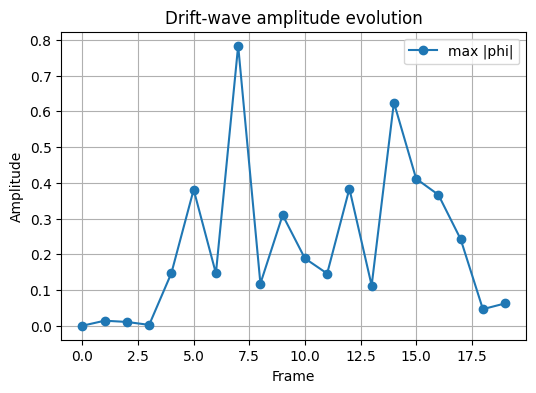

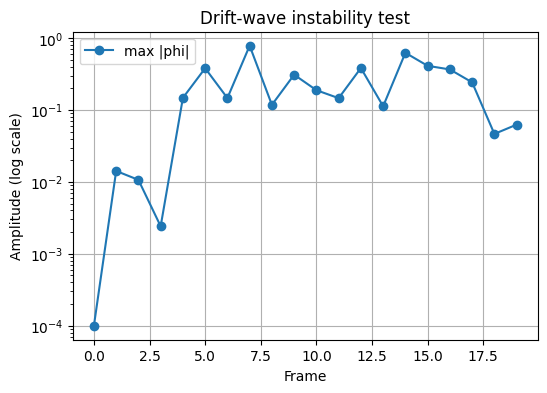

In [15]:
# ============================================================
# Drift-wave instability diagnostic
# Measures growth of potential amplitude
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import postgkyl as pg
import os

basedir = "/dartfs-hpc/rc/home/7/f006xp7/gkeyll_tests/hase_to_instability_ky_mode/"

# number of frames you saved in Lua
nFrames = 20

amp = []
time = []

for step in range(nFrames):

    fname = f"{basedir}/drift_wave_instability-phi_{step}.gkyl"

    if not os.path.exists(fname):
        continue

    data = pg.data.GData(fname)
    interp = pg.data.GInterpModal(data, 1, 'ms')

    grid, phi = interp.interpolate()

    phi2d = phi[:,:,0]

    # amplitude measure
    amp.append(np.max(np.abs(phi2d)))

    # approximate simulation time
    time.append(step)

amp = np.array(amp)
time = np.array(time)

# ------------------------------------------------
# Plot amplitude
# ------------------------------------------------

plt.figure(figsize=(6,4))

plt.plot(time, amp, 'o-', label="max |phi|")

plt.xlabel("Frame")
plt.ylabel("Amplitude")
plt.title("Drift-wave amplitude evolution")

plt.grid()
plt.legend()

plt.show()


# ------------------------------------------------
# Log plot to check exponential growth
# ------------------------------------------------

plt.figure(figsize=(6,4))

plt.semilogy(time, amp, 'o-', label="max |phi|")

plt.xlabel("Frame")
plt.ylabel("Amplitude (log scale)")
plt.title("Drift-wave instability test")

plt.grid()
plt.legend()

plt.show()

# Seeded mode amplitude

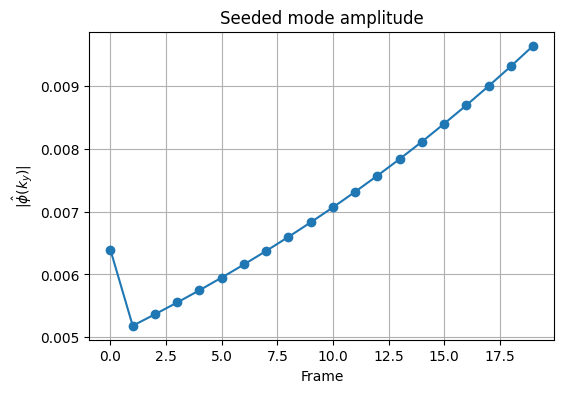

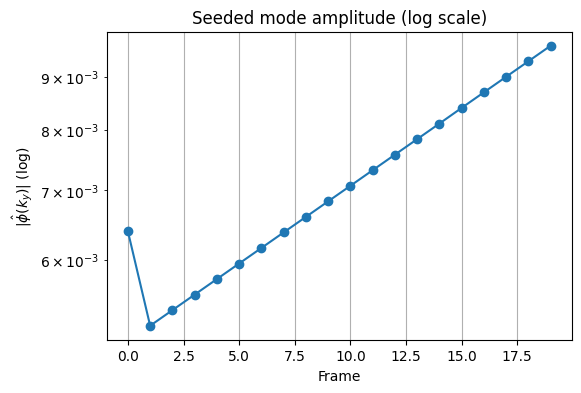

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
import postgkyl as pg

basedir = "/dartfs-hpc/rc/home/7/f006xp7/gkeyll_tests/hase_to_instability_ky_mode/"
nFrames = 20

# domain size
Ly = 40.0
ky0 = 2.0*np.pi/10.0   # set this to whatever you used in the Lua

amps = []
frames = []

for step in range(nFrames):
    fname = f"{basedir}/drift_wave_instability-phi_{step}.gkyl"
    if not os.path.exists(fname):
        continue

    data = pg.data.GData(fname)
    interp = pg.data.GInterpModal(data, 1, 'ms')
    grid, fld = interp.interpolate()

    x = grid[0]
    y = grid[1]
    phi = fld[:, :, 0]

    # use cell centers in y if needed
    y_centers = 0.5*(y[:-1] + y[1:]) if len(y) == phi.shape[1] + 1 else y

    # average over x to isolate ky structure
    phi_y = np.mean(phi, axis=0)

    # Fourier coefficient at seeded ky
    mode = np.abs(np.sum(phi_y * np.exp(-1j*ky0*y_centers)))

    amps.append(mode)
    frames.append(step)

amps = np.array(amps)
frames = np.array(frames)

plt.figure(figsize=(6,4))
plt.plot(frames, amps, 'o-')
plt.xlabel("Frame")
plt.ylabel(r"$|\hat{\phi}(k_y)|$")
plt.title("Seeded mode amplitude")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.semilogy(frames, amps, 'o-')
plt.xlabel("Frame")
plt.ylabel(r"$|\hat{\phi}(k_y)|$ (log)")
plt.title("Seeded mode amplitude (log scale)")
plt.grid(True)
plt.show()

# Drift-wave frequency diagnostic

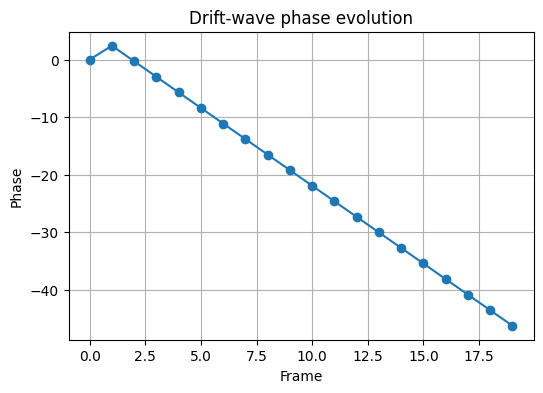

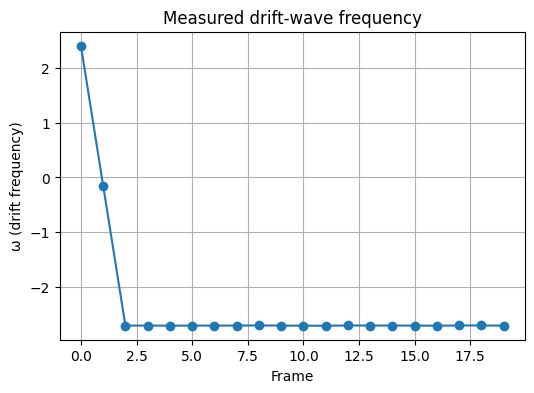

Average drift-wave frequency = -2.3189864855654316


In [17]:
# =====================================================
# Drift-wave frequency diagnostic
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
import postgkyl as pg
import os

basedir = "/dartfs-hpc/rc/home/7/f006xp7/gkeyll_tests/hase_to_instability_ky_mode/"
nFrames = 20

Ly = 40.0
ky0 = 2*np.pi/10.0

amps = []
phases = []
frames = []

for step in range(nFrames):

    fname = f"{basedir}/drift_wave_instability-phi_{step}.gkyl"
    if not os.path.exists(fname):
        continue

    data = pg.data.GData(fname)
    interp = pg.data.GInterpModal(data, 1, 'ms')
    grid, fld = interp.interpolate()

    x = grid[0]
    y = grid[1]
    phi = fld[:,:,0]

    # cell centers
    y_centers = 0.5*(y[:-1]+y[1:]) if len(y)==phi.shape[1]+1 else y

    # average over x
    phi_y = np.mean(phi, axis=0)

    # Fourier coefficient of seeded mode
    mode = np.sum(phi_y * np.exp(-1j*ky0*y_centers))

    amps.append(np.abs(mode))
    phases.append(np.angle(mode))
    frames.append(step)

amps = np.array(amps)
phases = np.unwrap(np.array(phases))   # remove 2π jumps
frames = np.array(frames)

# ----------------------------------
# Plot phase evolution
# ----------------------------------

plt.figure(figsize=(6,4))
plt.plot(frames, phases, 'o-')
plt.xlabel("Frame")
plt.ylabel("Phase")
plt.title("Drift-wave phase evolution")
plt.grid()
plt.show()

# ----------------------------------
# Estimate frequency
# ----------------------------------

omega = np.gradient(phases, frames)

plt.figure(figsize=(6,4))
plt.plot(frames, omega, 'o-')
plt.xlabel("Frame")
plt.ylabel("ω (drift frequency)")
plt.title("Measured drift-wave frequency")
plt.grid()
plt.show()

print("Average drift-wave frequency =", np.mean(omega))

# Drift-wave energy spectrum E(ky)

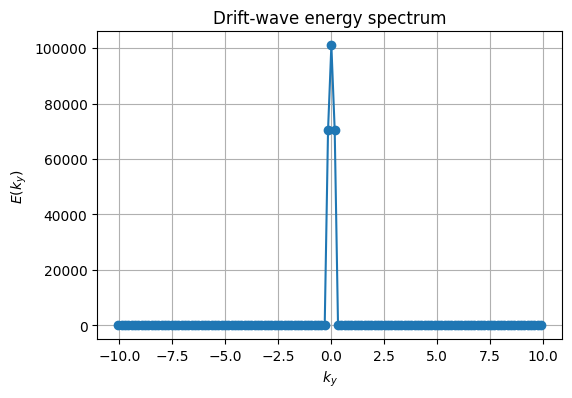

In [18]:
# =====================================================
# Drift-wave energy spectrum E(ky)
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
import postgkyl as pg

# choose which frame to analyze
step = 19

fname = f"{basedir}/drift_wave_instability-phi_{step}.gkyl"

data = pg.data.GData(fname)
interp = pg.data.GInterpModal(data,1,'ms')
grid, fld = interp.interpolate()

x = grid[0]
y = grid[1]
phi = fld[:,:,0]

Nx, Ny = phi.shape

# Fourier transform
phi_fft = np.fft.fft2(phi)
phi_fft = np.fft.fftshift(phi_fft)

energy = np.abs(phi_fft)**2

# ky axis
Ly = y[-1] - y[0]
ky = np.fft.fftshift(np.fft.fftfreq(Ny, d=Ly/Ny))*2*np.pi

# integrate over kx
Eky = np.sum(energy, axis=0)

plt.figure(figsize=(6,4))
plt.plot(ky, Eky, 'o-')
plt.xlabel(r"$k_y$")
plt.ylabel(r"$E(k_y)$")
plt.title("Drift-wave energy spectrum")
plt.grid(True)
plt.show()

# 2D drift wave spectrum

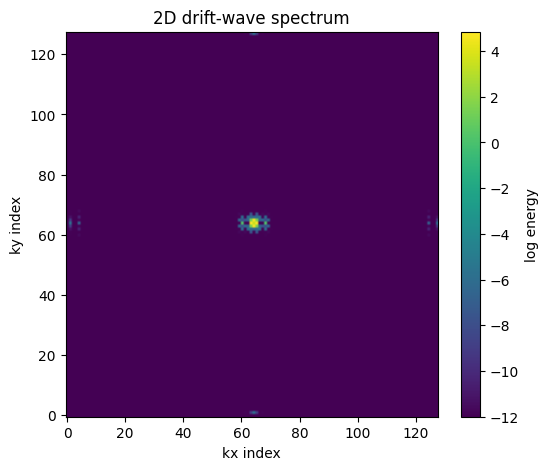

In [19]:
phi_fft = np.fft.fftshift(np.fft.fft2(phi))
energy = np.abs(phi_fft)**2

plt.figure(figsize=(6,5))
plt.imshow(np.log10(energy + 1e-12), origin='lower', aspect='auto')
plt.colorbar(label="log energy")
plt.title("2D drift-wave spectrum")
plt.xlabel("kx index")
plt.ylabel("ky index")
plt.show()

# Flux transport and confinement degradation

In [21]:
# =====================================================
# Cross-field transport diagnostic
# Γx = < n' vEx >
# =====================================================

import numpy as np
import postgkyl as pg
import matplotlib.pyplot as plt
import os

nFrames = 19

Gamma = []
frames = []

for step in range(nFrames):

    phi_file = f"{basedir}/drift_wave_instability-phi_{step}.gkyl"
    zeta_file = f"{basedir}/drift_wave_instability-zeta_{step}.gkyl"

    if not os.path.exists(phi_file):
        continue

    # load phi
    data_phi = pg.data.GData(phi_file)
    interp_phi = pg.data.GInterpModal(data_phi,1,'ms')
    grid, fld = interp_phi.interpolate()

    phi = fld[:,:,0]

    # load density-like field (second evolved variable)
    data_z = pg.data.GData(zeta_file)
    interp_z = pg.data.GInterpModal(data_z,1,'ms')
    grid, fld = interp_z.interpolate()

    n = fld[:,:,0]

    # compute vEx
    dy = (grid[1][-1]-grid[1][0])/phi.shape[1]
    dphi_dy = np.gradient(phi, dy, axis=1)

    vEx = -dphi_dy

    # fluctuations
    nprime = n - np.mean(n)

    # transport
    Gamma_x = np.mean(nprime * vEx)

    Gamma.append(Gamma_x)
    frames.append(step)

Gamma = np.array(Gamma)
frames = np.array(frames)

plt.figure(figsize=(6,4))
plt.plot(frames, Gamma, 'o-')
plt.xlabel("Frame")
plt.ylabel(r"$\Gamma_x$")
plt.title("Cross-field particle transport")
plt.grid(True)
plt.show()

AttributeError: module 'adios2' has no attribute 'open'

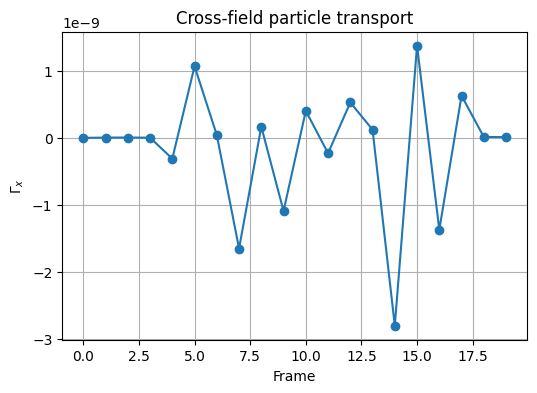

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import postgkyl as pg
import os

nFrames = 20

Gamma = []
frames = []

for step in range(nFrames):

    fluid_file = f"{basedir}/drift_wave_instability-fluid_{step}.gkyl"
    phi_file   = f"{basedir}/drift_wave_instability-phi_{step}.gkyl"

    if not os.path.exists(fluid_file):
        continue

    # load density-like field
    data_n = pg.data.GData(fluid_file)
    interp_n = pg.data.GInterpModal(data_n,1,'ms')
    grid, fld = interp_n.interpolate()

    n = fld[:,:,0]

    # load phi
    data_phi = pg.data.GData(phi_file)
    interp_phi = pg.data.GInterpModal(data_phi,1,'ms')
    grid, fld = interp_phi.interpolate()

    phi = fld[:,:,0]

    # grid spacing
    dy = (grid[1][-1] - grid[1][0]) / phi.shape[1]

    # ExB velocity
    dphi_dy = np.gradient(phi, dy, axis=1)
    vEx = -dphi_dy

    # density fluctuation
    nprime = n - np.mean(n)

    # cross-field transport
    Gamma_x = np.mean(nprime * vEx)

    Gamma.append(Gamma_x)
    frames.append(step)

Gamma = np.array(Gamma)

plt.figure(figsize=(6,4))
plt.plot(frames, Gamma, 'o-')
plt.xlabel("Frame")
plt.ylabel(r"$\Gamma_x$")
plt.title("Cross-field particle transport")
plt.grid()
plt.show()